# Notebook 01 — Exploration des données Orange Money
**Projet :** Modèle 4 — Détection d'anomalies sur commissions et frais  
**Auteur :** Koceila SALEM — RA&FM  
**Version :** 2.0 (notebook amélioré)  
**Objectif :** Comprendre la structure du fichier `OM_Koceila.csv` (13.2 Go) sans le charger entièrement en RAM, valider les hypothèses de modélisation, identifier les pièges qualité.

---

## Plan du notebook

| # | Section | Objectif |
|---|---------|----------|
| 0 | Imports & configuration | Paramètres centralisés, logging |
| 1 | Diagnostic encoding/séparateur | Identifier la bonne combinaison |
| 2 | Comptage rapide des lignes | Estimer le volume total |
| 3 | Échantillonnage stratifié | Éviter les biais temporels |
| 4 | Qualité des données | Manquants, zéros, types, outliers |
| 5 | Répartition métier | SERVICE_TYPE, TRANSFER_STATUS, IS_FINANCIAL |
| 6 | Statistiques financières | Signature normale par service |
| 7 | Plage temporelle | Couverture et granularité |
| 8 | Distributions & corrélations | Calibrer les features du Modèle 4 |
| 9 | Analyse des valeurs aberrantes | Anomalies visibles dans l'échantillon |
| 10 | Validation des hypothèses | Check-list go/no-go |
| 11 | Synthèse & décisions | Paramètres pour le notebook 02 |

> **Important :** ce notebook ne fait QUE de l'exploration. Aucune écriture sur disque, aucune modélisation.

## 0. Imports et configuration

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import sys
import time
import random
import warnings
import logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
log = logging.getLogger('OM_exploration')

print(f"Python  : {sys.version.split()[0]}")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Run at  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Python  : 3.12.10
Pandas  : 2.2.1
NumPy   : 1.26.4
Run at  : 2026-05-04 12:21:05


In [31]:
# ═══════════════════════════════════════════════════════════════════
#  PARAMÈTRES CENTRALISÉS — à ajuster ici uniquement
# ═══════════════════════════════════════════════════════════════════
CSV_PATH = r'C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv.csv'
SAMPLE_SIZE        = 100_000          # lignes pour l'échantillon principal
RANDOM_SAMPLE_SIZE = 50_000           # lignes pour l'échantillon aléatoire
RANDOM_SEED        = 42
N_COLS_ATTENDUES   = 76               # colonnes décrites dans le specs Orange

ENCODING_CANDIDATS  = ['latin-1', 'utf-8', 'cp1252']
SEPARATEUR_CANDIDATS = ['|', ';', ',', '\t']

# Colonnes financières du Modèle 4
COLS_FINANCIERES = [
    'TRANSACTION_AMOUNT',
    'COMMISSIONS_PAID',
    'COMMISSIONS_RECEIVED',
    'COMMISSIONS_OTHERS',
    'SERVICE_CHARGE_RECEIVED',
    'SERVICE_CHARGE_PAID',
    'TAXES'
]

# Colonnes identifiants & statut
COL_ID      = 'TRANSFER_ID'
COL_SERVICE = 'SERVICE_TYPE'
COL_STATUS  = 'TRANSFER_STATUS'
COL_FIN     = 'IS_FINANCIAL'
COL_DATE    = 'CREATED_ON'          # ou 'TRANSFER_DATETIME'

# Valeurs attendues
STATUS_SUCCESS = 'TS'
IS_FIN_OUI     = 'Y'

# ── Vérification fichier ─────────────────────────────────────────────────────
path = Path(CSV_PATH)
if path.exists():
    taille_go = path.stat().st_size / (1024**3)
    log.info(f"Fichier trouvé : {path.name}  ({taille_go:.2f} Go)")
else:
    log.warning(f"Fichier introuvable : {CSV_PATH}")
    log.warning("Mets à jour CSV_PATH ci-dessus avant de continuer.")

12:21:05 | INFO | Fichier trouvé : OM_Koceila.csv.csv  (13.21 Go)


## 1. Diagnostic : encoding et séparateur

On lit uniquement les premiers octets du fichier pour éviter tout chargement inutile.  
La combinaison qui retourne **≈ 76 colonnes** est la bonne.

In [32]:
def detecter_encoding_separateur(path, n_bytes=20_000):
    """
    Teste toutes les combinaisons encoding × séparateur.
    Retourne un DataFrame trié par nb_colonnes DESC.
    """
    resultats = []
    for enc in ENCODING_CANDIDATS:
        try:
            with open(path, 'r', encoding=enc, errors='replace') as f:
                lignes = [f.readline() for _ in range(5)]
            for sep in SEPARATEUR_CANDIDATS:
                nb_cols_par_ligne = [len(l.split(sep)) for l in lignes if l.strip()]
                nb_cols = int(np.median(nb_cols_par_ligne)) if nb_cols_par_ligne else 0
                variance = int(np.std(nb_cols_par_ligne)) if nb_cols_par_ligne else 999
                resultats.append({
                    'encoding'   : enc,
                    'separateur' : repr(sep),
                    'nb_colonnes': nb_cols,
                    'variance'   : variance,   # faible = séparateur stable
                    'extrait'    : lignes[0][:120].strip()
                })
        except Exception as e:
            log.warning(f"Encoding {enc} : {e}")

    df_res = pd.DataFrame(resultats).sort_values(['nb_colonnes', 'variance'], ascending=[False, True])
    return df_res

diag_enc = detecter_encoding_separateur(CSV_PATH)
display(diag_enc.head(10))

# Sélection automatique de la meilleure combinaison
best = diag_enc.iloc[0]
ENCODING   = best['encoding']
SEPARATEUR = best['separateur'].strip("'")
log.info(f"Encoding retenu  : {ENCODING}")
log.info(f"Séparateur retenu: {repr(SEPARATEUR)}")

,encoding,separateur,nb_colonnes,variance,extrait
0,latin-1,'|',80,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
4,utf-8,'|',80,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
8,cp1252,'|',80,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
1,latin-1,';',1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
2,latin-1,"','",1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
3,latin-1,'\t',1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
5,utf-8,';',1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
6,utf-8,"','",1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
7,utf-8,'\t',1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...
9,cp1252,';',1,0,RECEIVER_USER_ID|SENDER_USER_ID|TRANSACTION_AM...


12:21:05 | INFO | Encoding retenu  : latin-1
12:21:05 | INFO | Séparateur retenu: '|'


## 2. Comptage rapide des lignes

Estimation du volume total sans charger le fichier.  
*Sur 13 Go, l'opération prend entre 30 et 90 secondes.*

In [33]:
def compter_lignes_rapide(path, encoding=ENCODING, chunk_size=4_000_000):
    """
    Compte les lignes en streaming par blocs binaires — 3× plus rapide
    que l'itération ligne par ligne en Python.
    """
    log.info("Comptage des lignes en cours...")
    debut = time.time()
    nb = 0
    with open(path, 'rb') as f:
        while True:
            bloc = f.read(chunk_size)
            if not bloc:
                break
            nb += bloc.count(b'\n')
    duree = time.time() - debut
    nb_data = nb - 1  # on retire l'en-tête
    log.info(f"Total  : {nb_data:,} lignes de données (hors en-tête)")
    log.info(f"Durée  : {duree:.1f}s")
    log.info(f"Débit  : {(path.stat().st_size / duree / 1024**2):.0f} Mo/s")
    return nb_data

nb_lignes_total = compter_lignes_rapide(Path(CSV_PATH))

# Estimations opérationnelles
print(f"\n{'-'*50}")
print(f"  Lignes totales       : {nb_lignes_total:>15,}")
print(f"  Couverture 12 mois   : {nb_lignes_total/12:>15,.0f} txn/mois")
print(f"  Couverture jours (12M): {nb_lignes_total/365:>15,.0f} txn/jour")
print(f"  Poids estimé (64-bit) : {nb_lignes_total * 76 * 8 / 1024**3:>14.1f} Go RAM si tout chargé")
print(f"{'-'*50}")

12:21:05 | INFO | Comptage des lignes en cours...
12:21:27 | INFO | Total  : 25,456,467 lignes de données (hors en-tête)
12:21:27 | INFO | Durée  : 21.7s
12:21:27 | INFO | Débit  : 622 Mo/s



--------------------------------------------------
  Lignes totales       :      25,456,467
  Couverture 12 mois   :       2,121,372 txn/mois
  Couverture jours (12M):          69,744 txn/jour
  Poids estimé (64-bit) :           14.4 Go RAM si tout chargé
--------------------------------------------------


## 3. Échantillonnage

On charge **deux échantillons** pour éviter le biais de début de fichier :

- `df_head` : les 100k premières lignes (structure, colonnes, types)
- `df_rand` : 50k lignes aléatoires (représentativité des distributions)

In [34]:
# ── Échantillon de tête ──────────────────────────────────────────────────────
log.info(f"Lecture des {SAMPLE_SIZE:,} premières lignes...")
debut = time.time()

df_head = pd.read_csv(
    CSV_PATH,
    sep=SEPARATEUR,
    encoding=ENCODING,
    nrows=SAMPLE_SIZE,
    low_memory=False,
    on_bad_lines='warn'
)
duree = time.time() - debut
log.info(f"df_head : {df_head.shape[0]:,} lignes × {df_head.shape[1]} colonnes en {duree:.1f}s")
log.info(f"RAM     : {df_head.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")

12:21:27 | INFO | Lecture des 100,000 premières lignes...
12:21:29 | INFO | df_head : 100,000 lignes × 80 colonnes en 2.0s
12:21:31 | INFO | RAM     : 265.1 Mo


In [35]:
# ── Échantillon aléatoire (stratifié temporellement) ─────────────────────────
log.info(f"Construction de l'échantillon aléatoire ({RANDOM_SAMPLE_SIZE:,} lignes)...")

random.seed(RANDOM_SEED)
# On choisit RANDOM_SAMPLE_SIZE indices parmi les lignes de données (pas l'en-tête)
lignes_skip = sorted(
    random.sample(range(1, nb_lignes_total + 1),
                  nb_lignes_total - RANDOM_SAMPLE_SIZE)
)

debut = time.time()
df_rand = pd.read_csv(
    CSV_PATH,
    sep=SEPARATEUR,
    encoding=ENCODING,
    skiprows=lignes_skip,
    low_memory=False,
    on_bad_lines='warn'
)
duree = time.time() - debut
log.info(f"df_rand : {df_rand.shape[0]:,} lignes × {df_rand.shape[1]} colonnes en {duree:.1f}s")

# On travaille principalement avec df_rand pour les distributions
df_sample = df_rand.copy()
log.info("df_sample = df_rand (échantillon aléatoire retenu pour la suite)")

12:21:31 | INFO | Construction de l'échantillon aléatoire (50,000 lignes)...
12:24:57 | INFO | df_rand : 50,000 lignes × 80 colonnes en 156.0s
12:24:57 | INFO | df_sample = df_rand (échantillon aléatoire retenu pour la suite)


In [36]:
# ── Vue structure ────────────────────────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  STRUCTURE DU FICHIER")
print(f"{'═'*60}")
print(f"  Colonnes trouvées : {df_sample.shape[1]}")
print(f"  Attendues         : {N_COLS_ATTENDUES}")
delta = df_sample.shape[1] - N_COLS_ATTENDUES
statut = '✅' if abs(delta) <= 2 else '❌'
print(f"  Écart             : {delta:+d}  {statut}")
print()

# Inventaire des colonnes avec leurs types
col_info = pd.DataFrame({
    'colonne': df_sample.columns,
    'dtype'  : df_sample.dtypes.values,
    'non_null': df_sample.notna().sum().values,
    'pct_null': (df_sample.isna().mean() * 100).round(1).values,
    'exemple' : [str(df_sample[c].dropna().iloc[0])[:40] if df_sample[c].notna().any() else 'NaN'
                 for c in df_sample.columns]
})
display(col_info)


════════════════════════════════════════════════════════════
  STRUCTURE DU FICHIER
════════════════════════════════════════════════════════════
  Colonnes trouvées : 80
  Attendues         : 76
  Écart             : +4  ❌



,colonne,dtype,non_null,pct_null,exemple
0,RECEIVER_USER_ID,object,49854,0.30,PT151029.0941.198838
1,SENDER_USER_ID,object,49998,0.00,PT210811.1443.305254
2,TRANSACTION_AMOUNT,float64,50000,0.00,1000.0
3,COMMISSIONS_PAID,float64,50000,0.00,0.0
4,COMMISSIONS_RECEIVED,float64,50000,0.00,0.0
...,...,...,...,...,...
75,SENDER_WALLET_NAME,object,49855,0.30,Normal
76,RECIEVER_WALLET_NAME,object,49852,0.30,Normal
77,SENDER_USER_TYPE,object,49855,0.30,SUBSCRIBER
78,RECEIVER_USER_TYPE,object,49852,0.30,CHANNEL


## 4. Qualité des données

Point critique pour le Modèle 4 : si les commissions sont à > 95% à zéro, l'Isolation Forest sera aveugle au signal réel.

In [37]:
def diagnostic_qualite(df, cols):
    """
    Diagnostic complet par colonne financière :
    NaN, zéros, négatifs, statistiques robustes, IQR-outliers.
    """
    rows = []
    for col in cols:
        if col not in df.columns:
            log.warning(f"Colonne absente : {col}")
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        nan_after_cast = s.isna().sum() - df[col].isna().sum()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers_iqr = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
        rows.append({
            'colonne'       : col,
            'pct_null'      : f"{s.isna().mean()*100:.1f}%",
            'cast_erreurs'  : nan_after_cast,
            'pct_zeros'     : f"{(s==0).mean()*100:.1f}%",
            'pct_negatifs'  : f"{(s<0).mean()*100:.1f}%",
            'min'           : s.min(),
            'p5'            : s.quantile(0.05),
            'mediane'       : s.median(),
            'moyenne'       : s.mean(),
            'p95'           : s.quantile(0.95),
            'max'           : s.max(),
            'outliers_IQR'  : outliers_iqr,
            'alerte'        : ('🔴 zéros dominants' if (s==0).mean() > 0.95
                               else '🟡 beaucoup de nulls' if s.isna().mean() > 0.3
                               else '🟢 OK')
        })
    return pd.DataFrame(rows)

diag_qualite = diagnostic_qualite(df_sample, COLS_FINANCIERES)
display(diag_qualite)

,colonne,pct_null,cast_erreurs,pct_zeros,pct_negatifs,min,p5,mediane,moyenne,p95,max,outliers_IQR,alerte
0,TRANSACTION_AMOUNT,0.0%,0,0.0%,0.0%,1.00,500.00,"2,000.00","69,443.52","210,000.00","100,000,000.00",7738,🟢 OK
1,COMMISSIONS_PAID,0.0%,0,62.2%,0.0%,0.00,0.00,0.00,125.75,735.00,"17,110.00",7247,🟢 OK
2,COMMISSIONS_RECEIVED,0.0%,0,99.8%,0.0%,0.00,0.00,0.00,0.15,0.00,"1,250.00",109,🔴 zéros dominants
3,COMMISSIONS_OTHERS,0.0%,0,99.9%,0.0%,0.00,0.00,0.00,658.76,0.00,"31,138,100.00",48,🔴 zéros dominants
4,SERVICE_CHARGE_RECEIVED,0.0%,0,77.0%,0.0%,0.00,0.00,0.00,290.80,"1,900.00","53,900.00",11484,🟢 OK
5,SERVICE_CHARGE_PAID,0.0%,0,99.9%,0.0%,0.00,0.00,0.00,0.77,0.00,"7,200.00",51,🔴 zéros dominants
6,TAXES,0.0%,0,100.0%,0.0%,0.00,0.00,0.00,0.00,0.00,0.00,0,🔴 zéros dominants


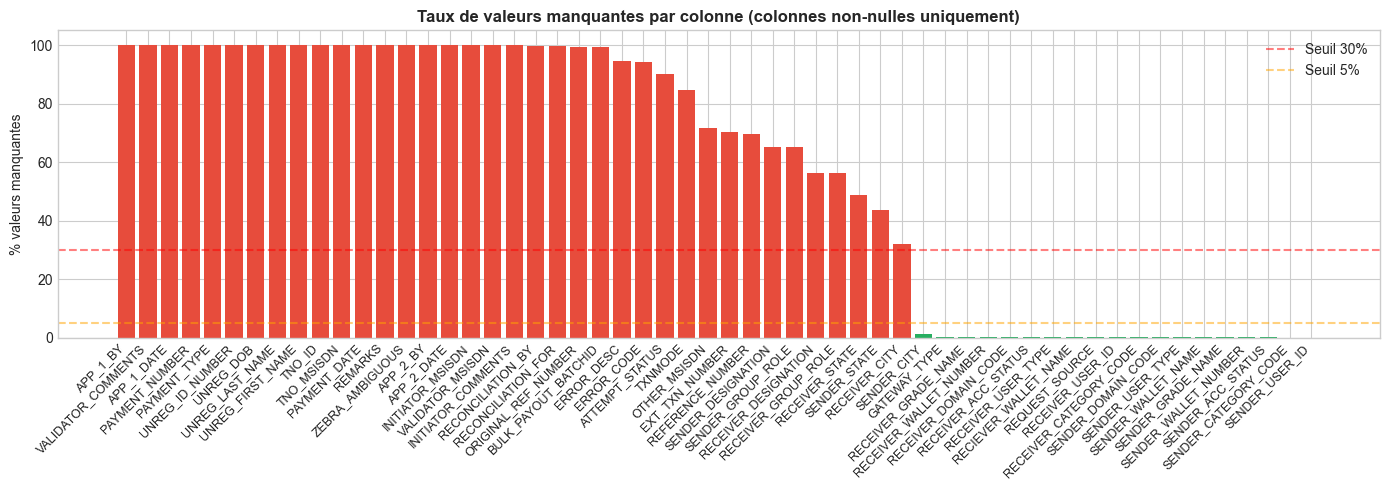

Colonnes sans aucune valeur manquante : 24/80


In [38]:
# ── Heatmap des valeurs manquantes (toutes colonnes) ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
pct_null = df_sample.isna().mean().sort_values(ascending=False)
pct_null_filtre = pct_null[pct_null > 0]

if len(pct_null_filtre) == 0:
    ax.text(0.5, 0.5, 'Aucune valeur manquante détectée', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
else:
    bars = ax.bar(range(len(pct_null_filtre)), pct_null_filtre.values * 100,
                  color=['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.05 else '#27ae60'
                         for v in pct_null_filtre.values])
    ax.set_xticks(range(len(pct_null_filtre)))
    ax.set_xticklabels(pct_null_filtre.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('% valeurs manquantes')
    ax.set_title('Taux de valeurs manquantes par colonne (colonnes non-nulles uniquement)', fontweight='bold')
    ax.axhline(30, color='red', linestyle='--', alpha=0.5, label='Seuil 30%')
    ax.axhline(5, color='orange', linestyle='--', alpha=0.5, label='Seuil 5%')
    ax.legend()

plt.tight_layout()
plt.show()
print(f"Colonnes sans aucune valeur manquante : {(pct_null == 0).sum()}/{len(pct_null)}")

## 5. Répartition métier

Compréhension du périmètre : quels services, quels statuts, quelle proportion de transactions financières.

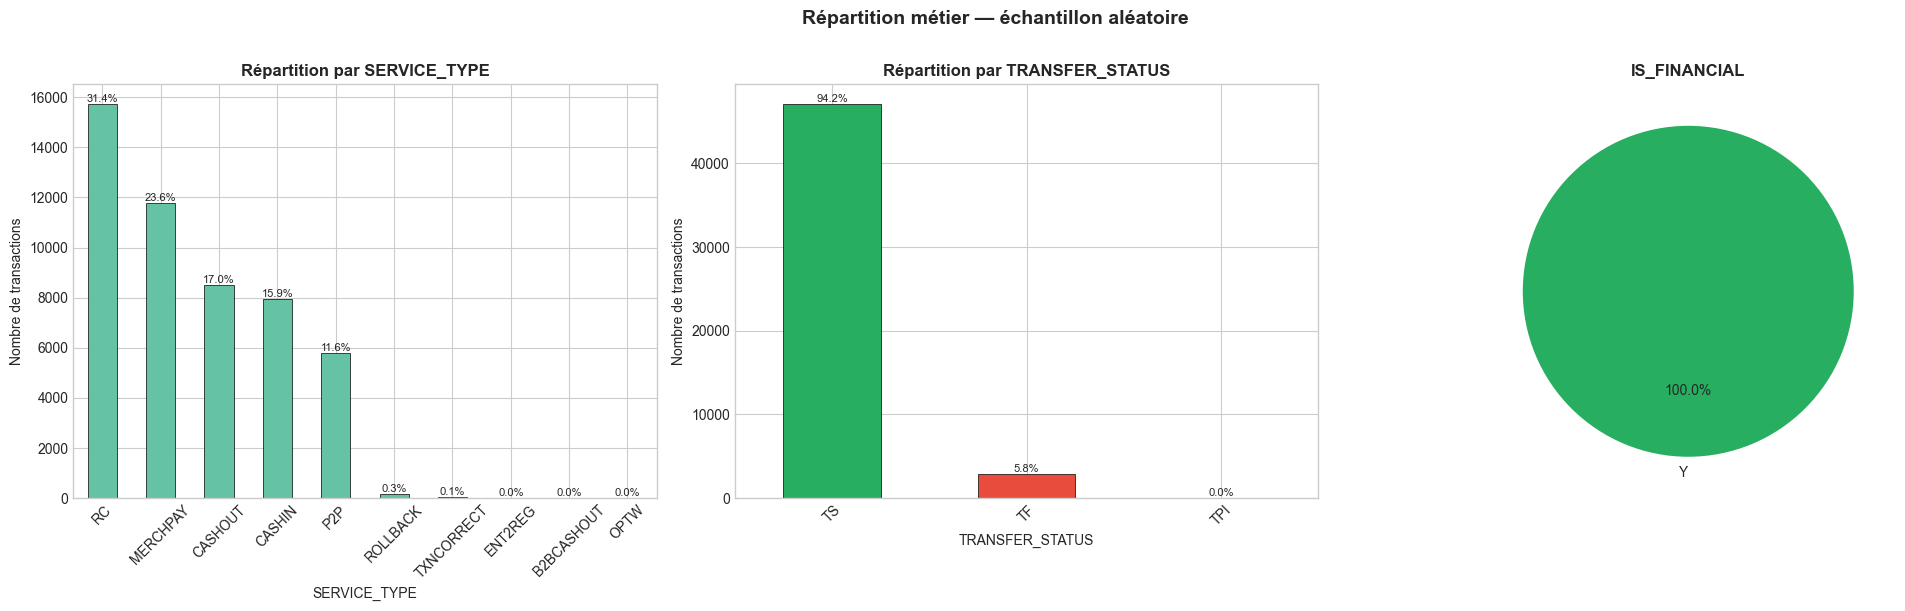

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── SERVICE_TYPE ─────────────────────────────────────────────────────────────
if COL_SERVICE in df_sample.columns:
    vc_service = df_sample[COL_SERVICE].value_counts()
    vc_service.plot(kind='bar', ax=axes[0], edgecolor='black', linewidth=0.5)
    axes[0].set_title('Répartition par SERVICE_TYPE', fontweight='bold')
    axes[0].set_ylabel('Nombre de transactions')
    axes[0].tick_params(axis='x', rotation=45)
    for p in axes[0].patches:
        pct = p.get_height() / len(df_sample) * 100
        axes[0].annotate(f'{pct:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

# ── TRANSFER_STATUS ──────────────────────────────────────────────────────────
if COL_STATUS in df_sample.columns:
    vc_status = df_sample[COL_STATUS].value_counts()
    colors = ['#27ae60' if s == STATUS_SUCCESS else '#e74c3c' for s in vc_status.index]
    vc_status.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Répartition par TRANSFER_STATUS', fontweight='bold')
    axes[1].set_ylabel('Nombre de transactions')
    axes[1].tick_params(axis='x', rotation=45)
    for p in axes[1].patches:
        pct = p.get_height() / len(df_sample) * 100
        axes[1].annotate(f'{pct:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

# ── IS_FINANCIAL ─────────────────────────────────────────────────────────────
if COL_FIN in df_sample.columns:
    vc_fin = df_sample[COL_FIN].value_counts()
    vc_fin.plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                colors=['#27ae60', '#95a5a6'], startangle=90)
    axes[2].set_title('IS_FINANCIAL', fontweight='bold')
    axes[2].set_ylabel('')

plt.suptitle('Répartition métier — échantillon aléatoire', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

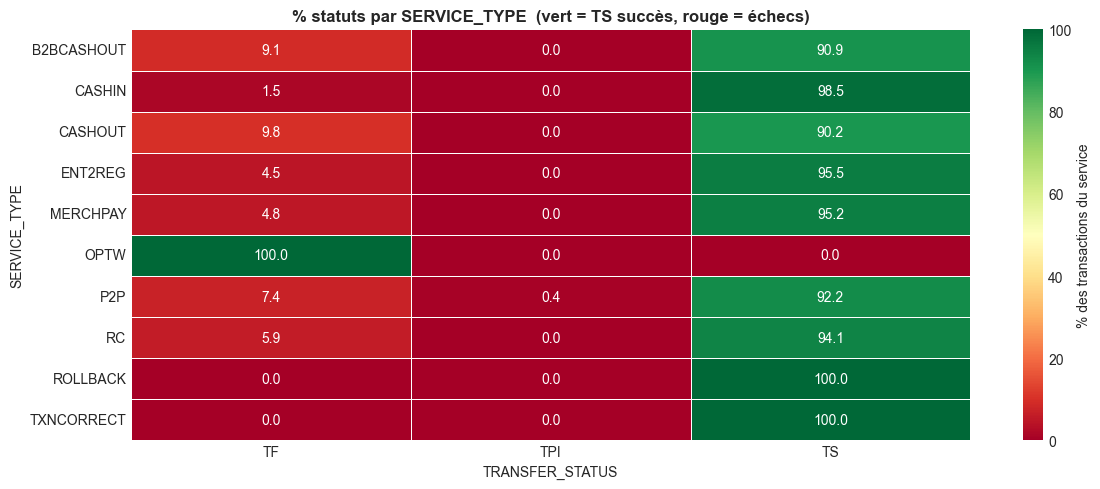


Taux de succès (TS) par service :


TRANSFER_STATUS,taux_TS_%
SERVICE_TYPE,
ROLLBACK,100.00
TXNCORRECT,100.00
CASHIN,98.50
ENT2REG,95.50
MERCHPAY,95.20
RC,94.10
P2P,92.20
B2BCASHOUT,90.90
CASHOUT,90.20


In [40]:
# ── Croisement SERVICE_TYPE × TRANSFER_STATUS ────────────────────────────────
if COL_SERVICE in df_sample.columns and COL_STATUS in df_sample.columns:
    pivot = pd.crosstab(
        df_sample[COL_SERVICE],
        df_sample[COL_STATUS],
        normalize='index'
    ).mul(100).round(1)
    
    fig, ax = plt.subplots(figsize=(12, max(5, len(pivot) * 0.5)))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': '% des transactions du service'})
    ax.set_title('% statuts par SERVICE_TYPE  (vert = TS succès, rouge = échecs)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nTaux de succès (TS) par service :")
    if STATUS_SUCCESS in pivot.columns:
        display(pivot[[STATUS_SUCCESS]].rename(columns={STATUS_SUCCESS: 'taux_TS_%'})
                .sort_values('taux_TS_%', ascending=False))

## 6. Statistiques financières par SERVICE_TYPE

Tableau pivot central du Modèle 4 : il révèle la **signature financière normale** de chaque service.  
Les services à commissions nulles seront **exclus du périmètre** de l'Isolation Forest.

In [41]:
# ── Filtrage périmètre Modèle 4 ──────────────────────────────────────────────
df_filtre = df_sample.copy()

masque_fin = pd.Series([True] * len(df_filtre))
if COL_FIN in df_filtre.columns:
    masque_fin = df_filtre[COL_FIN].astype(str).str.upper() == IS_FIN_OUI

masque_ts = pd.Series([True] * len(df_filtre))
if COL_STATUS in df_filtre.columns:
    masque_ts = df_filtre[COL_STATUS] == STATUS_SUCCESS

df_filtre = df_filtre[masque_fin & masque_ts].copy()

pct_retenu = len(df_filtre) / len(df_sample) * 100
log.info(f"Après filtrage IS_FINANCIAL=Y + TRANSFER_STATUS=TS : {len(df_filtre):,} lignes ({pct_retenu:.1f}%)")

# Cast numérique + vérification
for col in COLS_FINANCIERES:
    if col in df_filtre.columns:
        avant = df_filtre[col].isna().sum()
        df_filtre[col] = pd.to_numeric(df_filtre[col], errors='coerce')
        apres = df_filtre[col].isna().sum()
        if apres > avant:
            log.warning(f"{col} : {apres - avant} valeurs non-numériques converties en NaN")

12:25:00 | INFO | Après filtrage IS_FINANCIAL=Y + TRANSFER_STATUS=TS : 47,095 lignes (94.2%)


In [42]:
# ── Tableau de signature financière ─────────────────────────────────────────
if COL_SERVICE in df_filtre.columns:
    id_col = COL_ID if COL_ID in df_filtre.columns else df_filtre.columns[0]
    
    agg_dict = {id_col: 'count'}
    for col in COLS_FINANCIERES:
        if col in df_filtre.columns:
            agg_dict[col] = ['median', 'mean', 'std']
    
    stats_raw = df_filtre.groupby(COL_SERVICE).agg(agg_dict)
    stats_raw.columns = ['_'.join(c).strip('_') for c in stats_raw.columns]
    stats_raw = stats_raw.rename(columns={f'{id_col}_count': 'nb_transactions'})
    
    # Marge nette = moyenne des (com_recue + frais_recus - com_payee) par transaction
    if all(c in df_filtre.columns for c in ['COMMISSIONS_RECEIVED', 'SERVICE_CHARGE_RECEIVED', 'COMMISSIONS_PAID']):
        df_filtre['marge_nette'] = (
            df_filtre['COMMISSIONS_RECEIVED'].fillna(0)
            + df_filtre['SERVICE_CHARGE_RECEIVED'].fillna(0)
            - df_filtre['COMMISSIONS_PAID'].fillna(0)
        )
        marge_par_service = df_filtre.groupby(COL_SERVICE)['marge_nette'].agg(['median', 'sum']).round(2)
        marge_par_service.columns = ['marge_nette_mediane', 'marge_nette_totale']
        stats_raw = stats_raw.join(marge_par_service)
    
    stats_display = stats_raw.sort_values('nb_transactions', ascending=False)
    display(stats_display)
    
    # Alerte services à marge négative
    if 'marge_nette_mediane' in stats_display.columns:
        neg = stats_display[stats_display['marge_nette_mediane'] < 0]
        if len(neg) > 0:
            print(f"\n🔴 Services avec marge nette médiane NÉGATIVE (fuite potentielle !) :")
            display(neg[['nb_transactions', 'marge_nette_mediane', 'marge_nette_totale']])

,nb_transactions,TRANSACTION_AMOUNT_median,TRANSACTION_AMOUNT_mean,TRANSACTION_AMOUNT_std,COMMISSIONS_PAID_median,COMMISSIONS_PAID_mean,COMMISSIONS_PAID_std,COMMISSIONS_RECEIVED_median,COMMISSIONS_RECEIVED_mean,COMMISSIONS_RECEIVED_std,COMMISSIONS_OTHERS_median,COMMISSIONS_OTHERS_mean,COMMISSIONS_OTHERS_std,SERVICE_CHARGE_RECEIVED_median,SERVICE_CHARGE_RECEIVED_mean,SERVICE_CHARGE_RECEIVED_std,SERVICE_CHARGE_PAID_median,SERVICE_CHARGE_PAID_mean,SERVICE_CHARGE_PAID_std,TAXES_median,TAXES_mean,TAXES_std,marge_nette_mediane,marge_nette_totale
SERVICE_TYPE,,,,,,,,,,,,,,,,,,,,,,,,
RC,14788,"1,000.00","1,205.24","2,224.85",21.25,28.74,88.12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-21.25,"-425,077.00"
MERCHPAY,11234,"1,000.00","14,532.81","173,236.50",0.00,0.00,0.00,0.00,0.22,9.49,0.00,142.72,"5,943.39",0.00,47.80,497.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"539,460.18"
CASHIN,7826,"15,700.00","107,967.25","364,896.21",63.00,189.70,356.92,0.00,0.16,14.13,0.00,0.00,0.00,0.00,90.38,"1,456.20",0.00,0.00,0.00,0.00,0.00,0.00,-63.00,"-776,018.56"
CASHOUT,7670,"20,000.00","101,151.17","401,642.54",254.00,556.28,975.05,0.00,0.00,0.00,0.00,0.00,0.00,550.00,"1,364.20","2,719.34",0.00,0.00,0.00,0.00,0.00,0.00,282.00,"6,196,801.28"
P2P,5344,"20,000.00","275,060.24","2,308,456.62",0.00,18.48,201.82,0.00,0.00,0.00,0.00,"5,863.56","425,951.22",250.00,523.69,906.56,0.00,0.00,0.00,0.00,0.00,0.00,250.00,"2,699,859.08"
ROLLBACK,151,500.00,924.98,783.72,0.00,0.00,0.00,23.25,26.31,31.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.25,"3,973.56"
TXNCORRECT,51,"5,000.00","41,450.98","96,044.75",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,140.00,758.43,"1,262.24",0.00,0.00,0.00,0.00,0.00
ENT2REG,21,"51,000.00","189,977.23","268,741.82",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,184.86,508.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"3,882.00"
B2BCASHOUT,10,"45,000.00","193,530.00","272,014.48",595.00,"1,150.70",971.66,0.00,0.00,0.00,0.00,0.00,0.00,"1,300.00","2,620.00","2,605.36",0.00,0.00,0.00,0.00,0.00,0.00,720.00,"14,693.00"



🔴 Services avec marge nette médiane NÉGATIVE (fuite potentielle !) :


,nb_transactions,marge_nette_mediane,marge_nette_totale
SERVICE_TYPE,,,
RC,14788,-21.25,"-425,077.00"
CASHIN,7826,-63.00,"-776,018.56"


In [43]:
# ── Identifier les services commissionnés vs non-commissionnés ───────────────
if 'COMMISSIONS_RECEIVED' in df_filtre.columns and COL_SERVICE in df_filtre.columns:
    com_par_service = df_filtre.groupby(COL_SERVICE)['COMMISSIONS_RECEIVED'].agg(
        pct_non_nulle=lambda x: (x > 0).mean() * 100,
        mediane_non_nulle=lambda x: x[x > 0].median() if (x > 0).any() else 0,
        total=lambda x: x.sum()
    ).round(2).sort_values('pct_non_nulle', ascending=False)
    
    com_par_service['périmètre_M4'] = com_par_service['pct_non_nulle'].apply(
        lambda x: '✅ À inclure' if x > 1 else '❌ À exclure'
    )
    
    print("\nCommissions reçues par service (filtré TS uniquement) :")
    display(com_par_service)
    
    SERVICES_M4 = com_par_service[com_par_service['pct_non_nulle'] > 1].index.tolist()
    print(f"\n→ Services retenus pour le Modèle 4 : {SERVICES_M4}")


Commissions reçues par service (filtré TS uniquement) :


,pct_non_nulle,mediane_non_nulle,total,périmètre_M4
SERVICE_TYPE,,,,
ROLLBACK,64.90,23.25,"3,973.56",✅ À inclure
MERCHPAY,0.09,192.40,"2,514.65",❌ À exclure
CASHIN,0.01,"1,250.00","1,250.00",❌ À exclure
B2BCASHOUT,0.00,0.00,0.00,❌ À exclure
CASHOUT,0.00,0.00,0.00,❌ À exclure
ENT2REG,0.00,0.00,0.00,❌ À exclure
P2P,0.00,0.00,0.00,❌ À exclure
RC,0.00,0.00,0.00,❌ À exclure
TXNCORRECT,0.00,0.00,0.00,❌ À exclure



→ Services retenus pour le Modèle 4 : ['ROLLBACK']


## 7. Plage temporelle

Vérification de la couverture temporelle et de la granularité des données.

In [45]:
# ── Détection et parsing de la colonne date ──────────────────────────────────
COL_DATE_RETENU = None
formats_a_tester = ['%d/%m/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S', '%d-%m-%Y %H:%M:%S',
                    '%d/%m/%Y', '%Y-%m-%d', None]  # None = inférence pandas

for col_date_cand in ['CREATED_ON', 'TRANSFER_DATETIME', 'VALUE_DATE']:
    if col_date_cand not in df_sample.columns:
        continue
    
    for fmt in formats_a_tester:
        try:
            if fmt:
                parsed = pd.to_datetime(df_sample[col_date_cand], format=fmt, errors='coerce')
            else:
                parsed = pd.to_datetime(df_sample[col_date_cand], errors='coerce', dayfirst=True)
            
            pct_ok = parsed.notna().mean()
            if pct_ok > 0.95:
                df_sample[col_date_cand + '_dt'] = parsed
                COL_DATE_RETENU = col_date_cand + '_dt'
                log.info(f"Date retenue : {col_date_cand} | format : {fmt or 'auto'} | {pct_ok*100:.1f}% parsé")
                break
        except Exception:
            continue
    if COL_DATE_RETENU:
        break

if not COL_DATE_RETENU:
    log.warning("Aucune colonne date parsée correctement — section 7 partielle")

12:26:08 | INFO | Date retenue : CREATED_ON | format : %d/%m/%Y %H:%M:%S | 100.0% parsé


Période : 2025-08-31 11:10:20 → 2025-09-30 23:55:04
Durée   : 30 jours
NaN     : 0 (0.0%)


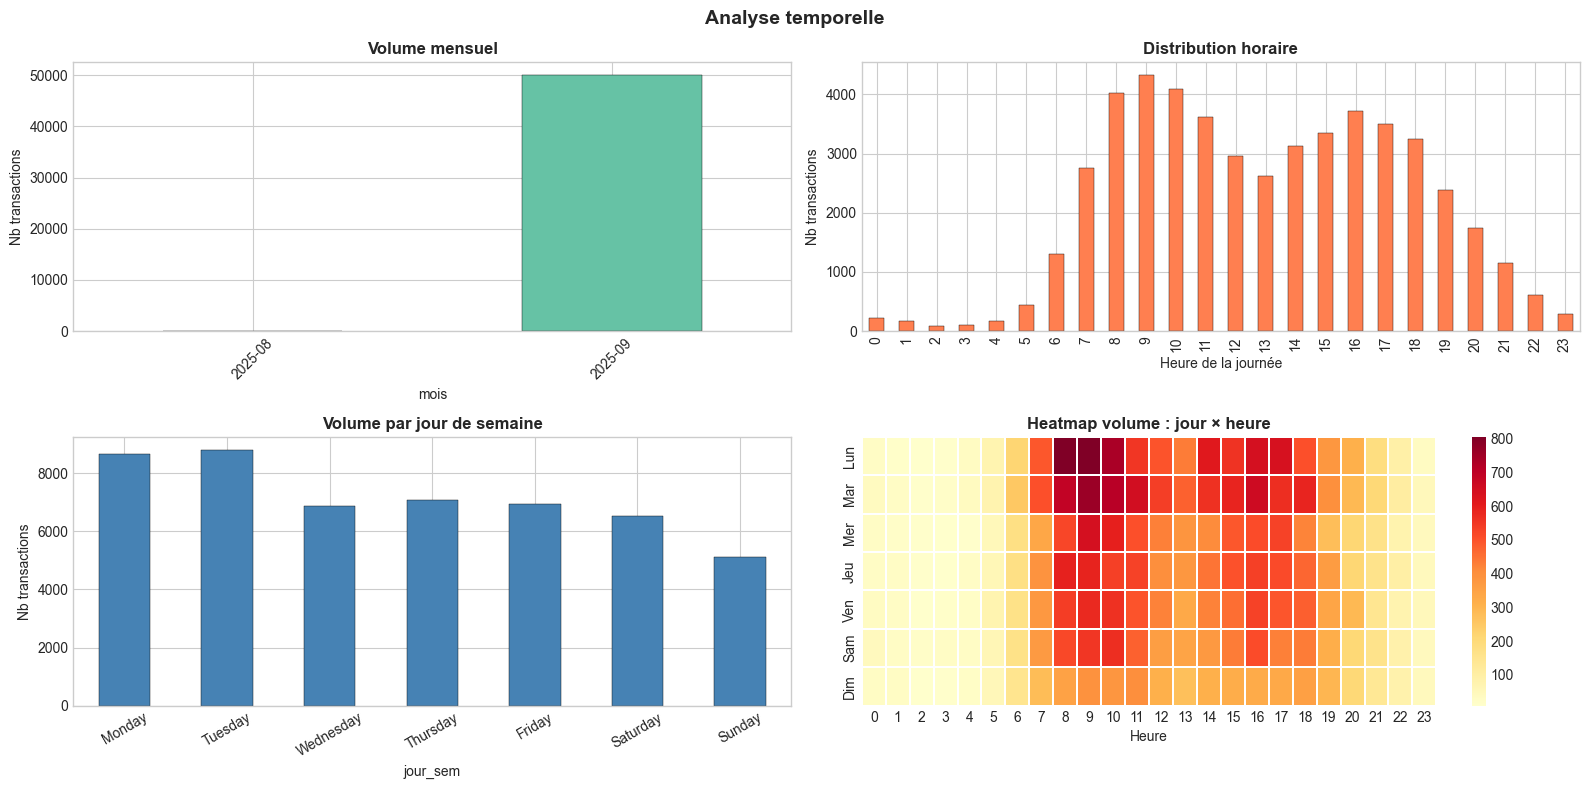

In [46]:
# ── Analyse temporelle ────────────────────────────────────────────────────────
if COL_DATE_RETENU and COL_DATE_RETENU in df_sample.columns:
    dt = df_sample[COL_DATE_RETENU]
    
    print(f"Période : {dt.min()} → {dt.max()}")
    print(f"Durée   : {(dt.max() - dt.min()).days} jours")
    print(f"NaN     : {dt.isna().sum()} ({dt.isna().mean()*100:.1f}%)")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    
    # Volume par mois
    df_sample['mois'] = dt.dt.to_period('M')
    vol_mois = df_sample.groupby('mois').size()
    vol_mois.plot(kind='bar', ax=axes[0,0], edgecolor='black', linewidth=0.3)
    axes[0,0].set_title('Volume mensuel', fontweight='bold')
    axes[0,0].set_ylabel('Nb transactions')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Volume par heure (intra-day)
    df_sample['heure'] = dt.dt.hour
    vol_heure = df_sample.groupby('heure').size()
    vol_heure.plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black', linewidth=0.3)
    axes[0,1].set_title('Distribution horaire', fontweight='bold')
    axes[0,1].set_ylabel('Nb transactions')
    axes[0,1].set_xlabel('Heure de la journée')
    
    # Volume par jour de la semaine
    df_sample['jour_sem'] = dt.dt.day_name()
    jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    vol_jour = df_sample.groupby('jour_sem').size().reindex(jours_ordre, fill_value=0)
    vol_jour.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black', linewidth=0.3)
    axes[1,0].set_title('Volume par jour de semaine', fontweight='bold')
    axes[1,0].set_ylabel('Nb transactions')
    axes[1,0].tick_params(axis='x', rotation=30)
    
    # Heatmap heure × jour
    df_sample['jour_sem_n'] = dt.dt.dayofweek
    heatmap_data = df_sample.groupby(['jour_sem_n','heure']).size().unstack(fill_value=0)
    heatmap_data.index = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'][:len(heatmap_data)]
    sns.heatmap(heatmap_data, ax=axes[1,1], cmap='YlOrRd', linewidths=0.1)
    axes[1,1].set_title('Heatmap volume : jour × heure', fontweight='bold')
    axes[1,1].set_xlabel('Heure')
    
    plt.suptitle('Analyse temporelle', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Distributions et corrélations

Les montants Orange Money suivent typiquement une distribution **log-normale** très skewed.  
On travaille en `log10` pour visualiser la forme réelle.

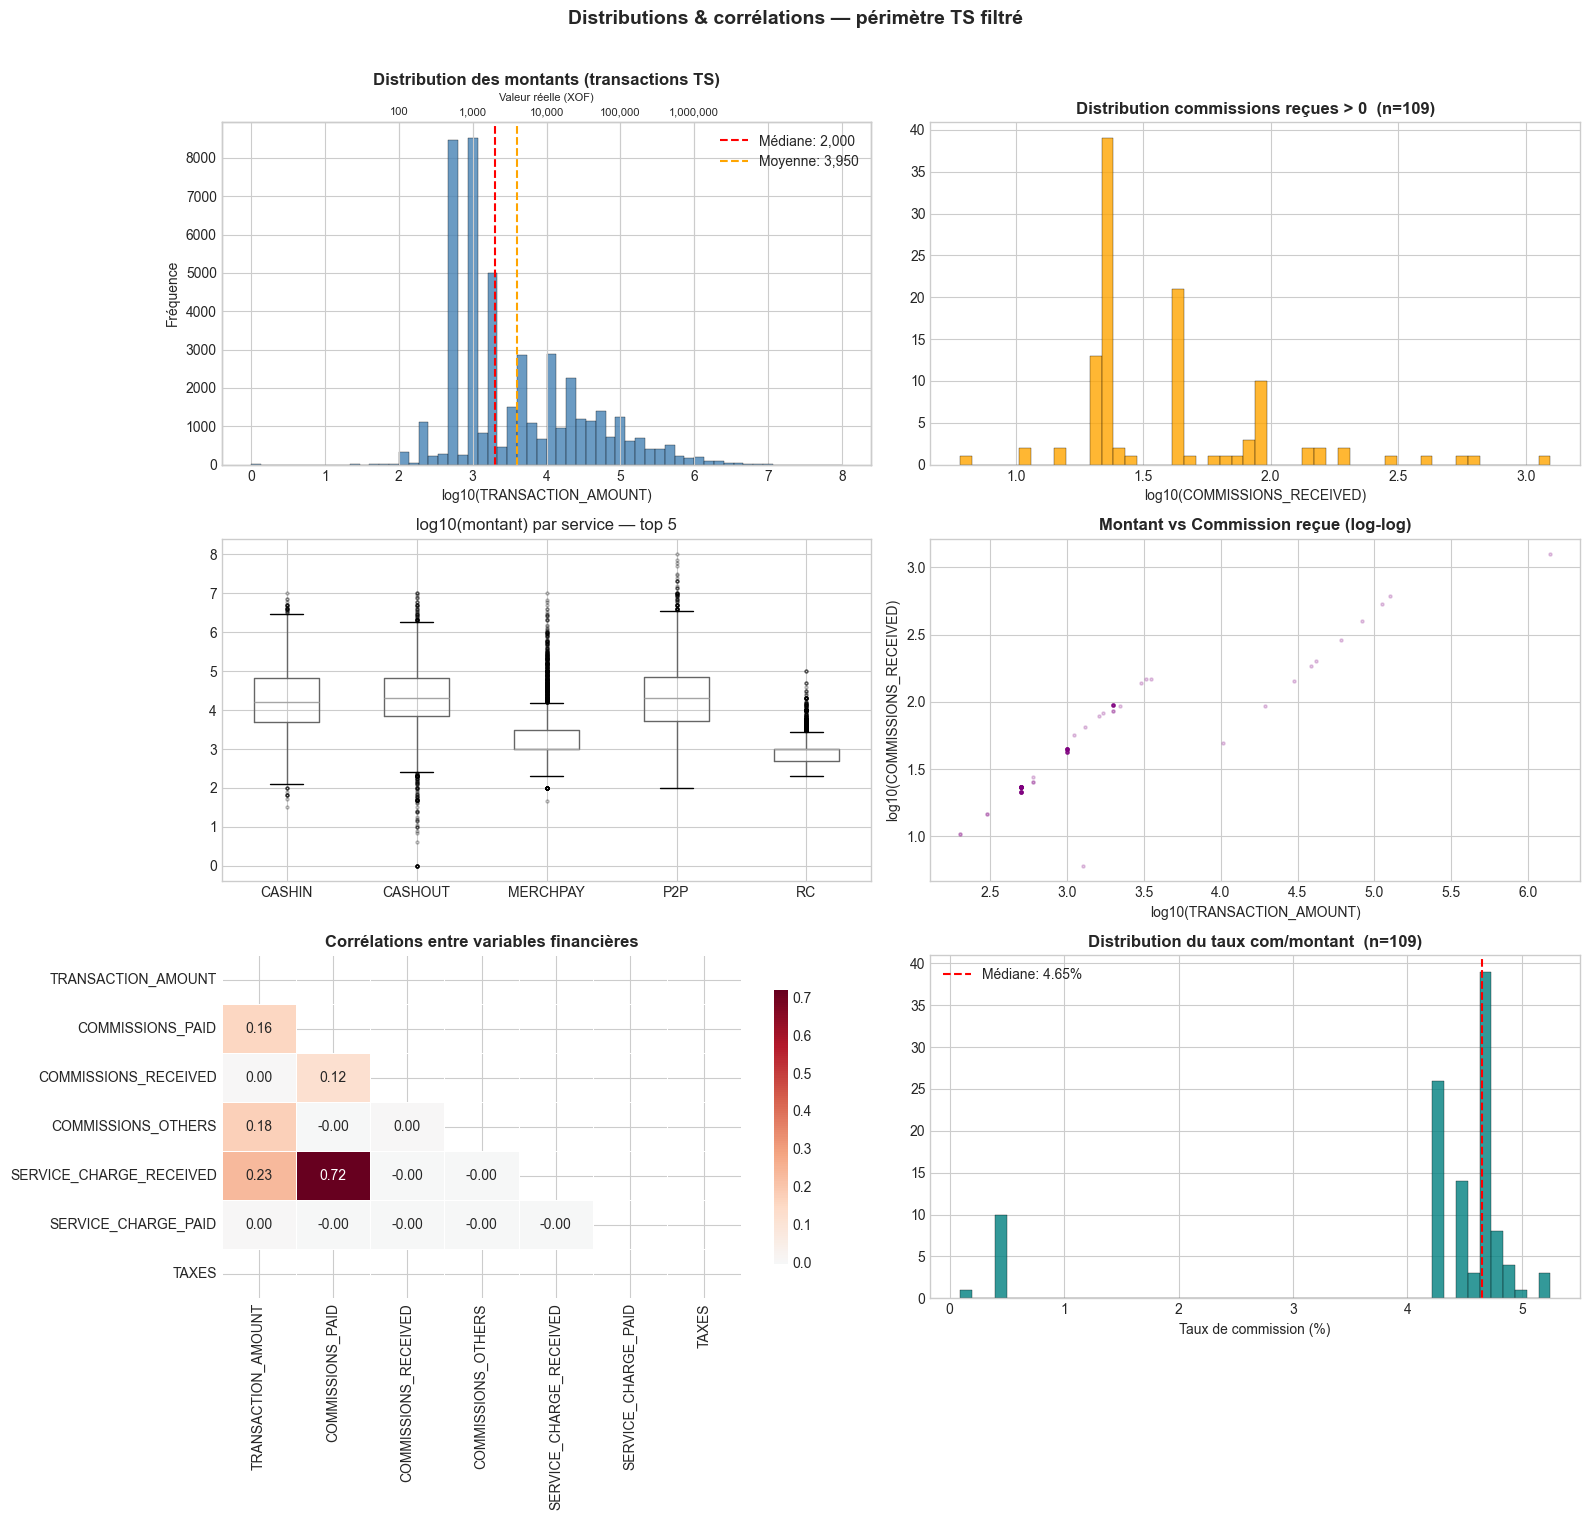

In [47]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# ── 1. Distribution log10(TRANSACTION_AMOUNT) ─────────────────────────────────
if 'TRANSACTION_AMOUNT' in df_filtre.columns:
    amt_pos = df_filtre['TRANSACTION_AMOUNT'][df_filtre['TRANSACTION_AMOUNT'] > 0].dropna()
    if len(amt_pos) > 0:
        log_amt = np.log10(amt_pos)
        axes[0,0].hist(log_amt, bins=60, edgecolor='black', linewidth=0.3, color='steelblue', alpha=0.8)
        axes[0,0].axvline(log_amt.median(), color='red', linestyle='--', label=f'Médiane: {10**log_amt.median():,.0f}')
        axes[0,0].axvline(log_amt.mean(), color='orange', linestyle='--', label=f'Moyenne: {10**log_amt.mean():,.0f}')
        axes[0,0].set_xlabel('log10(TRANSACTION_AMOUNT)')
        axes[0,0].set_ylabel('Fréquence')
        axes[0,0].set_title('Distribution des montants (transactions TS)', fontweight='bold')
        axes[0,0].legend()
        # Axe secondaire en valeurs réelles
        ax2 = axes[0,0].twiny()
        ticks = [2,3,4,5,6]
        ax2.set_xlim(axes[0,0].get_xlim())
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([f'{10**t:,.0f}' for t in ticks], fontsize=8)
        ax2.set_xlabel('Valeur réelle (XOF)', fontsize=8)

# ── 2. Distribution log10(COMMISSIONS_RECEIVED) ────────────────────────────
if 'COMMISSIONS_RECEIVED' in df_filtre.columns:
    com_pos = df_filtre['COMMISSIONS_RECEIVED'][df_filtre['COMMISSIONS_RECEIVED'] > 0].dropna()
    if len(com_pos) > 0:
        axes[0,1].hist(np.log10(com_pos), bins=50, edgecolor='black', linewidth=0.3, color='orange', alpha=0.8)
        axes[0,1].set_xlabel('log10(COMMISSIONS_RECEIVED)')
        axes[0,1].set_title(f'Distribution commissions reçues > 0  (n={len(com_pos):,})', fontweight='bold')
    else:
        axes[0,1].text(0.5, 0.5, 'Aucune commission reçue\n> 0 dans cet échantillon',
                       ha='center', va='center', transform=axes[0,1].transAxes,
                       fontsize=12, color='red')
        axes[0,1].set_title('COMMISSIONS_RECEIVED', fontweight='bold')

# ── 3. Boxplot log(montant) par service top 5 ─────────────────────────────
if COL_SERVICE in df_filtre.columns and 'TRANSACTION_AMOUNT' in df_filtre.columns:
    top5 = df_filtre[COL_SERVICE].value_counts().head(5).index
    df_box = df_filtre[df_filtre[COL_SERVICE].isin(top5) & (df_filtre['TRANSACTION_AMOUNT'] > 0)].copy()
    df_box['log_amount'] = np.log10(df_box['TRANSACTION_AMOUNT'])
    df_box.boxplot(column='log_amount', by=COL_SERVICE, ax=axes[1,0],
                   flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[1,0].set_title('log10(montant) par service — top 5', fontweight='bold')
    axes[1,0].set_xlabel('')
    plt.sca(axes[1,0])
    plt.title('log10(montant) par service — top 5')

# ── 4. Scatter montant vs commission (sous-échantillon) ────────────────────
if all(c in df_filtre.columns for c in ['TRANSACTION_AMOUNT', 'COMMISSIONS_RECEIVED']):
    mask = (df_filtre['TRANSACTION_AMOUNT'] > 0) & (df_filtre['COMMISSIONS_RECEIVED'] > 0)
    df_sc = df_filtre[mask].sample(min(5000, mask.sum()), random_state=RANDOM_SEED)
    axes[1,1].scatter(np.log10(df_sc['TRANSACTION_AMOUNT']),
                      np.log10(df_sc['COMMISSIONS_RECEIVED']),
                      alpha=0.2, s=5, c='purple')
    axes[1,1].set_xlabel('log10(TRANSACTION_AMOUNT)')
    axes[1,1].set_ylabel('log10(COMMISSIONS_RECEIVED)')
    axes[1,1].set_title('Montant vs Commission reçue (log-log)', fontweight='bold')

# ── 5. Heatmap corrélations ────────────────────────────────────────────────
cols_corr = [c for c in COLS_FINANCIERES if c in df_filtre.columns]
corr = df_filtre[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[2,0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[2,0].set_title('Corrélations entre variables financières', fontweight='bold')

# ── 6. Distribution taux de commission effectif ────────────────────────────
if all(c in df_filtre.columns for c in ['COMMISSIONS_RECEIVED', 'TRANSACTION_AMOUNT']):
    mask2 = (df_filtre['TRANSACTION_AMOUNT'] > 0) & (df_filtre['COMMISSIONS_RECEIVED'] > 0)
    taux_com = (df_filtre.loc[mask2, 'COMMISSIONS_RECEIVED']
                / df_filtre.loc[mask2, 'TRANSACTION_AMOUNT'] * 100)
    taux_ok = taux_com[(taux_com > 0) & (taux_com < 20)]
    if len(taux_ok) > 0:
        axes[2,1].hist(taux_ok, bins=50, edgecolor='black', linewidth=0.3, color='teal', alpha=0.8)
        axes[2,1].set_xlabel('Taux de commission (%)')
        axes[2,1].set_title(f'Distribution du taux com/montant  (n={len(taux_ok):,})', fontweight='bold')
        axes[2,1].axvline(taux_ok.median(), color='red', linestyle='--',
                          label=f'Médiane: {taux_ok.median():.2f}%')
        axes[2,1].legend()

plt.suptitle('Distributions & corrélations — périmètre TS filtré', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Analyse des valeurs aberrantes (anomalies visibles dans l'échantillon)

Avant de modéliser, on identifie les anomalies déjà visibles — elles serviront de **ground truth partielle** pour évaluer le Modèle 4.

In [49]:
anomalies_detectees = []

# ── A. Montants négatifs sur transactions TS ─────────────────────────────────
if 'TRANSACTION_AMOUNT' in df_filtre.columns:
    neg_amt = df_filtre[df_filtre['TRANSACTION_AMOUNT'] < 0]
    if len(neg_amt) > 0:
        anomalies_detectees.append({
            'type'      : 'Montant négatif (TS)',
            'nb'        : len(neg_amt),
            'pct'       : f'{len(neg_amt)/len(df_filtre)*100:.3f}%',
            'interprétation': 'Rollback ou erreur de saisie — à investiguer'
        })
        print(f"🔴 Transactions TS avec montant < 0 : {len(neg_amt)}")
        display(neg_amt[['TRANSACTION_AMOUNT'] + [c for c in [COL_SERVICE, COL_ID, COL_DATE] if c in neg_amt.columns]].head(10))

# ── B. Commission > Montant ──────────────────────────────────────────────────
if all(c in df_filtre.columns for c in ['COMMISSIONS_RECEIVED', 'TRANSACTION_AMOUNT']):
    mask_com_sup = (df_filtre['COMMISSIONS_RECEIVED'] > df_filtre['TRANSACTION_AMOUNT']) &                    (df_filtre['TRANSACTION_AMOUNT'] > 0)
    if mask_com_sup.sum() > 0:
        anomalies_detectees.append({
            'type'      : 'Commission > Montant',
            'nb'        : mask_com_sup.sum(),
            'pct'       : f'{mask_com_sup.mean()*100:.3f}%',
            'interprétation': '⚠️ Commission supérieure au montant — suspect (taux > 100%)'
        })
        print(f"\n🔴 Transactions où COMMISSIONS_RECEIVED > TRANSACTION_AMOUNT : {mask_com_sup.sum()}")
        display(df_filtre[mask_com_sup][COLS_FINANCIERES + [COL_SERVICE]].head(10))

# ── C. Outliers IQR par service ──────────────────────────────────────────────
if 'TRANSACTION_AMOUNT' in df_filtre.columns and COL_SERVICE in df_filtre.columns:
    outliers_service = []
    for svc, grp in df_filtre.groupby(COL_SERVICE):
        s = grp['TRANSACTION_AMOUNT'].dropna()
        if len(s) < 20:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        nb_out = ((s < q1 - 3*iqr) | (s > q3 + 3*iqr)).sum()
        if nb_out > 0:
            outliers_service.append({'SERVICE_TYPE': svc, 'outliers_3IQR': nb_out,
                                     'pct': f'{nb_out/len(s)*100:.2f}%',
                                     'q1': q1, 'q3': q3, 'max': s.max()})
    
    if outliers_service:
        df_out = pd.DataFrame(outliers_service).sort_values('outliers_3IQR', ascending=False)
        print(f"\n🟡 Outliers (3×IQR) sur TRANSACTION_AMOUNT par service :")
        display(df_out)
        anomalies_detectees.append({
            'type': 'Outliers montant (3×IQR)',
            'nb': df_out['outliers_3IQR'].sum(),
            'pct': '—',
            'interprétation': 'Candidats anomalies Modèle 4'
        })

# ── D. Doublons potentiels ───────────────────────────────────────────────────
if COL_ID in df_filtre.columns:
    nb_doublons = df_filtre[COL_ID].duplicated().sum()
    if nb_doublons > 0:
        anomalies_detectees.append({
            'type'      : 'TRANSFER_ID dupliqués',
            'nb'        : nb_doublons,
            'pct'       : f'{nb_doublons/len(df_filtre)*100:.3f}%',
            'interprétation': '⚠️ Doublons sur identifiant unique — vérifier'
        })

print(f"\n{'═'*60}")
print("  RÉCAPITULATIF DES ANOMALIES DÉTECTÉES")
print(f"{'═'*60}")
if anomalies_detectees:
    display(pd.DataFrame(anomalies_detectees))
else:
    print("  Aucune anomalie évidente détectée dans cet échantillon")


🟡 Outliers (3×IQR) sur TRANSACTION_AMOUNT par service :


,SERVICE_TYPE,outliers_3IQR,pct,q1,q3,max
2,MERCHPAY,1211,10.78%,"1,000.00","3,000.00","10,000,000.00"
4,RC,954,6.45%,500.00,"1,000.00","100,000.00"
0,CASHIN,771,9.85%,"5,000.00","65,000.00","10,000,000.00"
1,CASHOUT,635,8.28%,"7,000.00","66,000.00","10,000,000.00"
3,P2P,625,11.70%,"5,140.00","71,900.00","100,000,000.00"
5,ROLLBACK,6,3.97%,500.00,"1,000.00","5,000.00"
6,TXNCORRECT,5,9.80%,"1,300.00","27,000.00","550,000.00"



════════════════════════════════════════════════════════════
  RÉCAPITULATIF DES ANOMALIES DÉTECTÉES
════════════════════════════════════════════════════════════


,type,nb,pct,interprétation
0,Outliers montant (3×IQR),4207,—,Candidats anomalies Modèle 4


## 10. Validation des hypothèses du Modèle 4

Check-list à valider **avant** de passer au notebook 02.

In [51]:
checks = []

# H1 : Colonnes
delta_cols = abs(len(df_sample.columns) - N_COLS_ATTENDUES)
checks.append({
    'hypothèse': f'Nombre de colonnes ≈ {N_COLS_ATTENDUES}',
    'valeur_observée': str(len(df_sample.columns)),
    'seuil': f'|écart| ≤ 3',
    'statut': '✅' if delta_cols <= 3 else '❌'
})

# H2 : Commissions non nulles
if 'COMMISSIONS_RECEIVED' in df_filtre.columns and len(df_filtre) > 0:
    com_nn = (df_filtre['COMMISSIONS_RECEIVED'] > 0).mean()
    checks.append({
        'hypothèse': 'Au moins 1% des transactions TS ont COMMISSIONS_RECEIVED > 0',
        'valeur_observée': f'{com_nn*100:.2f}%',
        'seuil': '≥ 1%',
        'statut': '✅' if com_nn >= 0.01 else '⚠️ trop peu'
    })

# H3 : Plusieurs services commissionnés
if 'SERVICES_M4' in dir():
    checks.append({
        'hypothèse': 'Au moins 3 services avec commissions actives',
        'valeur_observée': str(len(SERVICES_M4)),
        'seuil': '≥ 3',
        'statut': '✅' if len(SERVICES_M4) >= 3 else '⚠️'
    })

# H4 : Transactions TS
if COL_STATUS in df_sample.columns:
    pct_ts = (df_sample[COL_STATUS] == STATUS_SUCCESS).mean()
    checks.append({
        'hypothèse': 'Présence suffisante de transactions TS',
        'valeur_observée': f'{pct_ts*100:.1f}%',
        'seuil': '≥ 50%',
        'statut': '✅' if pct_ts >= 0.5 else '⚠️ faible'
    })

# H5 : Dates parsables
if COL_DATE_RETENU and COL_DATE_RETENU in df_sample.columns:
    pct_date = df_sample[COL_DATE_RETENU].notna().mean()
    checks.append({
        'hypothèse': 'Colonne date parsable à > 99%',
        'valeur_observée': f'{pct_date*100:.1f}%',
        'seuil': '≥ 99%',
        'statut': '✅' if pct_date >= 0.99 else '⚠️'
    })
else:
    checks.append({
        'hypothèse': 'Colonne date parsable',
        'valeur_observée': 'Non parsée',
        'seuil': '≥ 99%',
        'statut': '❌'
    })

# H6 : Taille suffisante pour Isolation Forest
n_modele = len(df_filtre)
checks.append({
    'hypothèse': 'Périmètre ≥ 1000 transactions pour modélisation',
    'valeur_observée': f'{n_modele:,}',
    'seuil': '≥ 1 000',
    'statut': '✅' if n_modele >= 1000 else '❌'
})

# H7 : Pas d'encodage cassé (colonnes objet avec % non-ASCII > 10%)
if COL_SERVICE in df_sample.columns:
    sample_str = df_sample[COL_SERVICE].dropna().astype(str).str
    pct_ascii = sample_str.match(r'^[\x00-\x7F]+$').mean()
    checks.append({
        'hypothèse': 'SERVICE_TYPE lisible (ASCII > 90%)',
        'valeur_observée': f'{pct_ascii*100:.1f}%',
        'seuil': '≥ 90%',
        'statut': '✅' if pct_ascii >= 0.9 else '❌ encoding incorrect'
    })

df_checks = pd.DataFrame(checks)
display(df_checks)

nb_ok  = (df_checks['statut'] == '✅').sum()
nb_ko  = df_checks['statut'].str.startswith('❌').sum()
nb_avert = df_checks['statut'].str.startswith('⚠️').sum()

print(f"\n{'═'*50}")
print(f"  Résultat : {nb_ok}✅  {nb_avert}⚠️  {nb_ko}❌")
if nb_ko == 0 and nb_avert == 0:
    print("  → 🟢 GO — tu peux passer au notebook 02")
elif nb_ko == 0:
    print("  → 🟡 GO avec réserves — vérifie les avertissements avant le notebook 02")
else:
    print("  → 🔴 NO-GO — des problèmes bloquants doivent être réglés")
print(f"{'═'*50}")

,hypothèse,valeur_observée,seuil,statut
0,Nombre de colonnes ≈ 76,85,|écart| ≤ 3,❌
1,Au moins 1% des transactions TS ont COMMISSION...,0.23%,≥ 1%,⚠️ trop peu
2,Au moins 3 services avec commissions actives,1,≥ 3,⚠️
3,Présence suffisante de transactions TS,94.2%,≥ 50%,✅
4,Colonne date parsable à > 99%,100.0%,≥ 99%,✅
5,Périmètre ≥ 1000 transactions pour modélisation,"47,095",≥ 1 000,✅
6,SERVICE_TYPE lisible (ASCII > 90%),100.0%,≥ 90%,✅



══════════════════════════════════════════════════
  Résultat : 4✅  2⚠️  1❌
  → 🔴 NO-GO — des problèmes bloquants doivent être réglés
══════════════════════════════════════════════════


## 11. Synthèse et décisions pour le notebook 02

Ce bloc récapitule tous les paramètres à passer au pipeline d'agrégation.

In [ ]:
print("\n" + "═"*65)
print("  PARAMÈTRES POUR LE NOTEBOOK 02 — À COPIER")
print("═"*65)

print(f"\n# Fichier")
print(f"CSV_PATH   = r'{CSV_PATH}'")
print(f"ENCODING   = '{ENCODING}'")
print(f"SEPARATEUR = '{SEPARATEUR}'")
print(f"NB_LIGNES  = {nb_lignes_total:,}  # total estimé")

if COL_DATE_RETENU:
    print(f"\n# Date")
    print(f"COL_DATE   = '{COL_DATE_RETENU.replace('_dt','')}'  # colonne date retenue")

if 'SERVICES_M4' in dir() and SERVICES_M4:
    print(f"\n# Périmètre Modèle 4")
    print(f"SERVICES_M4 = {SERVICES_M4}  # services avec commissions actives")

print(f"\n# Colonnes financières confirmées dans le fichier")
cols_presentes = [c for c in COLS_FINANCIERES if c in df_filtre.columns]
print(f"COLS_FINANCIERES = {cols_presentes}")

print("\n" + "═"*65)
print("  POINTS D'ATTENTION")
print("═"*65)
if len(anomalies_detectees) > 0:
    for a in anomalies_detectees:
        print(f"  🔴 {a['type']} : {a['nb']} cas ({a['pct']}) — {a['interprétation']}")
else:
    print("  Aucune anomalie bloquante détectée.")

print("\n" + "═"*65)
print("  PROCHAINES ÉTAPES")
print("═"*65)
print("  1. Ouvrir 02_aggregation_pipeline.ipynb")
print("  2. Copier les paramètres ci-dessus")
print("  3. Construire les features par (SERVICE_TYPE, période)")
print("  4. Entraîner Isolation Forest sur le périmètre M4")
print("  5. Scorer toutes les transactions et exporter les anomalies")




═════════════════════════════════════════════════════════════════
  PARAMÈTRES POUR LE NOTEBOOK 02 — À COPIER
═════════════════════════════════════════════════════════════════

# Fichier
CSV_PATH   = r'C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv.csv'
ENCODING   = 'latin-1'
SEPARATEUR = '|'
NB_LIGNES  = 25,456,467  # total estimé

# Date
COL_DATE   = 'CREATED_ON'  # colonne date retenue

# Périmètre Modèle 4
SERVICES_M4 = ['ROLLBACK']  # services avec commissions actives

# Colonnes financières confirmées dans le fichier
COLS_FINANCIERES = ['TRANSACTION_AMOUNT', 'COMMISSIONS_PAID', 'COMMISSIONS_RECEIVED', 'COMMISSIONS_OTHERS', 'SERVICE_CHARGE_RECEIVED', 'SERVICE_CHARGE_PAID', 'TAXES']

═════════════════════════════════════════════════════════════════
  POINTS D'ATTENTION
═════════════════════════════════════════════════════════════════
  🔴 Outliers montant (3×IQR) : 4207 cas (—) — Candidats anomalies Modèle 4

═════════════════════════════════════════════════════════════